# 15.439 HW 5
**Alfredo Celedon Fuentes and Matthew Huggins**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
import cvxpy as cp
from tqdm.auto import tqdm

tqdm.pandas()

### Load Data

factors.xlsx
date – time and date at month close

factor_1 – first factor total return if money invested at period t-1

factor_2 – second factor total return if money invested at period t-1

factor_3 – third factor total return if money invested at period t-1

factor_4 – fourth factor total return if money invested at period t-1

factor_5 – fifth factor total return if money invested at period t-1

rf – risk free rate return if money invested at period t-1

In [ ]:
factors_df = pd.read_excel("factors.xlsx")
factors_df

,date,factor_1,factor_2,factor_3,factor_4,factor_5,rf
0,2031-01-31,0.0199,-0.0243,0.0082,-0.0076,0.0083,0.0001
1,2031-02-28,0.0349,0.0165,0.0127,-0.0194,0.0088,0.0001
2,2031-03-31,0.0046,0.0262,-0.0183,0.0176,-0.0003,0.0001
3,2031-04-29,0.0290,-0.0055,-0.0243,0.0101,-0.0080,0.0000
4,2031-05-31,-0.0127,-0.0062,-0.0212,0.0208,-0.0158,0.0000
...,...,...,...,...,...,...,...
103,2039-08-30,-0.0258,-0.0324,-0.0479,0.0056,-0.0068,0.0016
104,2039-09-30,0.0143,0.0026,0.0677,0.0184,0.0339,0.0018
105,2039-10-31,0.0206,0.0027,-0.0190,0.0043,-0.0095,0.0016
106,2039-11-29,0.0388,0.0045,-0.0199,-0.0163,-0.0125,0.0012


data.xlsx

date – time and date at month close

mrap_id – identifier

naics – North American Industry Classification System Code

price – average of bid-ask price at close

vol – trading volume for the period in 00's

ret – total return if money invested in security at period t-1

shrout – shares outstanding in 000’s


In [ ]:
data_df = pd.read_excel("data.xlsx")
data_df

,date,mrap_id,naics,price,vol,ret,shrout
0,2031-01-31,40101,511210.0,32.029999,5861822.0,0.024920,5052420.0
1,2031-02-28,40101,511210.0,32.900002,4033709.0,0.027162,5061000.0
2,2031-03-31,40101,511210.0,33.432499,6727022.0,0.016185,5060516.0
3,2031-04-29,40101,511210.0,35.959999,5360104.0,0.077395,5060516.0
4,2031-05-31,40101,511210.0,34.220001,5150245.0,-0.048387,5068000.0
...,...,...,...,...,...,...,...
95626,2039-08-30,63439,336111.0,225.610001,1340932.0,-0.066222,179127.0
95627,2039-09-30,63439,336111.0,240.869995,1365915.0,0.067639,180000.0
95628,2039-10-31,63439,336111.0,314.920013,2351125.0,0.307427,180245.0
95629,2039-11-29,63439,336111.0,329.940002,1578851.0,0.047695,180245.0


In [ ]:
print("Unique dates:",len(data_df['date'].unique()))
print("Unique IDS:",len(data_df['mrap_id'].unique()))

Unique dates: 108
Unique IDS: 1000


# Problem 1

In [ ]:
# Problem 1: Estimate factor loadings for each stock

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

factor_cols = ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']

# Make sure dates are datetime and data are sorted
data_df['date'] = pd.to_datetime(data_df['date'])
factors_df['date'] = pd.to_datetime(factors_df['date'])

data_df = data_df.sort_values(['mrap_id', 'date']).copy()
factors_df = factors_df.sort_values('date').copy()

# Basic checks
print("Unique stocks in data:", data_df['mrap_id'].nunique())
print("Unique factor dates:", factors_df['date'].nunique())
print("Duplicate stock-date rows:", data_df.duplicated(['mrap_id', 'date']).sum())
print("Duplicate factor dates:", factors_df.duplicated(['date']).sum())

Unique stocks in data: 1000
Unique factor dates: 108
Duplicate stock-date rows: 0
Duplicate factor dates: 0


In [ ]:
betas_rows = []
fitted_by_stock = {}

for mid, stock_df in data_df.groupby('mrap_id'):
    merged = (
        stock_df[['date', 'ret']]
        .merge(
            factors_df[['date'] + factor_cols],
            on='date',
            how='inner'
        )
        .dropna(subset=['ret'] + factor_cols)
        .sort_values('date')
    )

    # Skip names with no usable return history
    if merged.empty:
        continue

    X = merged[factor_cols].to_numpy()
    y = merged['ret'].to_numpy()

    # No intercept so Problem 2 matches epsilon = R - BF exactly
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ beta
    resid = y - fitted

    # Store betas
    row = {'mrap_id': mid}
    row.update(dict(zip(factor_cols, beta)))
    row['n_obs'] = len(merged)

    # Optional diagnostic
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - y.mean())**2)
    row['r2'] = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

    betas_rows.append(row)

    # Save fitted series for plotting later
    fitted_by_stock[mid] = pd.DataFrame({
        'date': merged['date'].values,
        'actual_ret': y,
        'fitted_ret': fitted
    })

betas_df = pd.DataFrame(betas_rows).sort_values('mrap_id').reset_index(drop=True)

# B matrix with stocks as rows and factors as columns
B = betas_df.set_index('mrap_id')[factor_cols]

print("B matrix shape:", B.shape)
display(betas_df.head())

B matrix shape: (999, 5)


,mrap_id,factor_1,factor_2,factor_3,factor_4,factor_5,n_obs,r2
0,61,1.223084,-0.318639,-0.081069,-0.665818,0.084739,44,0.417400
1,181,4.047314,-9.539827,5.618559,-24.037434,-7.200842,15,0.574068
2,201,1.394600,0.414062,-1.299894,-0.477249,0.597302,108,0.127506
3,224,1.086018,0.160528,-0.495849,-0.595824,-0.332655,108,0.501239
4,377,0.780153,0.406553,0.555263,0.260895,-0.336028,108,0.246363


In [ ]:
all_ids = set(data_df['mrap_id'].unique())
estimated_ids = set(betas_df['mrap_id'].unique())
missing_ids = sorted(all_ids - estimated_ids)

print("Stocks skipped because they had no usable return history:", missing_ids)

Stocks skipped because they had no usable return history: [np.int64(48091)]


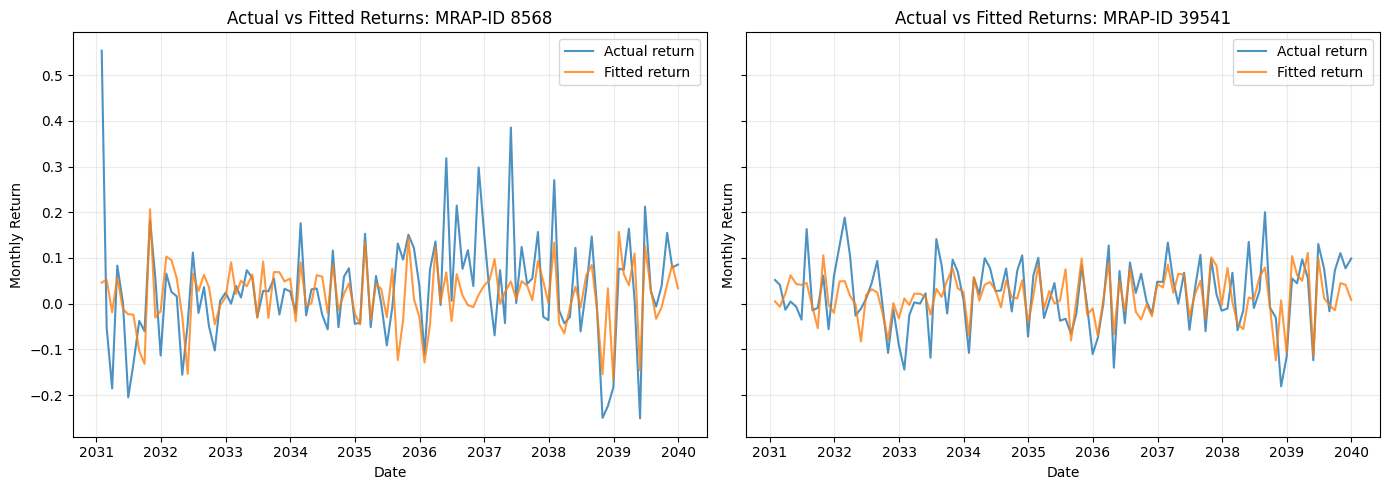

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, mid in zip(axes, [8568, 39541]):
    plot_df = fitted_by_stock[mid].copy()
    plot_df = plot_df.sort_values('date')

    ax.plot(plot_df['date'], plot_df['actual_ret'], label='Actual return', alpha=0.8)
    ax.plot(plot_df['date'], plot_df['fitted_ret'], label='Fitted return', alpha=0.8)
    ax.set_title(f'Actual vs Fitted Returns: MRAP-ID {mid}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Monthly Return')
    ax.grid(True, alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

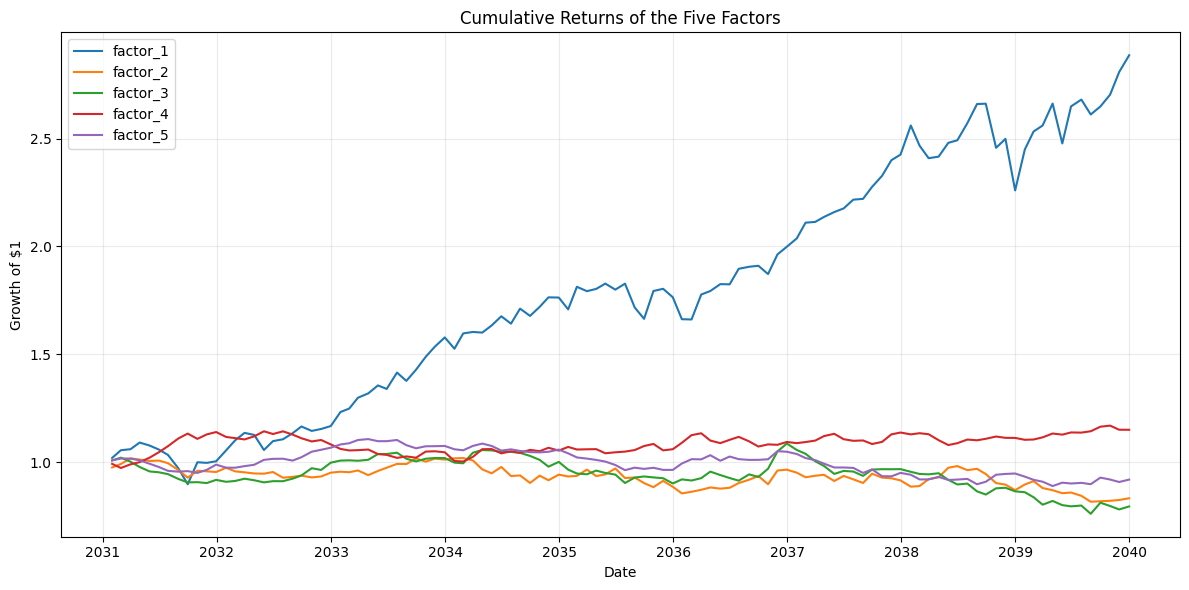

In [ ]:
factor_returns = factors_df.set_index('date')[factor_cols].sort_index()
cum_factors = (1 + factor_returns).cumprod()

plt.figure(figsize=(12, 6))
for col in factor_cols:
    plt.plot(cum_factors.index, cum_factors[col], label=col)

plt.title('Cumulative Returns of the Five Factors')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Problem 2

In [ ]:
# Problem 2: Idiosyncratic returns and covariance

common_ids = B.index.tolist()
common_dates = sorted(factors_df['date'].unique())

# Asset return matrix R: rows = stocks, columns = dates
R = (
    data_df.pivot(index='mrap_id', columns='date', values='ret')
    .reindex(index=common_ids, columns=common_dates)
    .sort_index()
)

# Factor return matrix F: rows = factors, columns = dates
F = (
    factors_df.set_index('date')[factor_cols]
    .reindex(common_dates)
    .T
)

# Factor-implied/systematic returns
BF = B @ F

# Residual returns matrix
epsilon = R - BF

print("R shape:", R.shape)
print("B shape:", B.shape)
print("F shape:", F.shape)
print("BF shape:", BF.shape)
print("epsilon shape:", epsilon.shape)

print("Residual returns matrix epsilon (first 5 stocks x first 8 dates):")
display(epsilon.iloc[:5, :8])

R shape: (999, 108)
B shape: (999, 5)
F shape: (5, 108)
BF shape: (999, 108)
epsilon shape: (999, 108)
Residual returns matrix epsilon (first 5 stocks x first 8 dates):


date,2031-01-31,2031-02-28,2031-03-31,2031-04-29,2031-05-31,2031-06-30,2031-07-29,2031-08-31
mrap_id,,,,,,,,
61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201,0.086729,-0.121208,-0.256539,0.009364,-0.035415,-0.005314,0.019554,0.021805
224,-0.021996,-0.006919,-0.016568,0.039493,-0.009104,-0.001757,-0.055461,0.011881
377,0.012300,0.058961,0.021138,-0.036073,0.039673,-0.107048,-0.001486,0.031250


In [ ]:
# Fill only for the matrix multiplication after keeping track of availability
epsilon_filled = epsilon.fillna(0.0)
mask = epsilon.notna().astype(float)

# Pairwise counts of overlapping observations
counts = mask.to_numpy() @ mask.to_numpy().T

# Idiosyncratic covariance estimator
Omega_epsilon_array = epsilon_filled.to_numpy() @ epsilon_filled.to_numpy().T

# Avoid divide-by-zero
Omega_epsilon_array = np.divide(
    Omega_epsilon_array,
    counts,
    out=np.full_like(Omega_epsilon_array, np.nan, dtype=float),
    where=counts > 0
)

Omega_epsilon = pd.DataFrame(
    Omega_epsilon_array,
    index=epsilon.index,
    columns=epsilon.index
)

print("Omega_epsilon shape:", Omega_epsilon.shape)
display(Omega_epsilon.iloc[:5, :5])

Omega_epsilon shape: (999, 999)


mrap_id,61,181,201,224,377
mrap_id,,,,,
61,0.002208,0.002620,0.000239,-0.000493,-0.000809
181,0.002620,0.031938,0.002982,-0.000094,0.001247
201,0.000239,0.002982,0.014468,0.000105,0.000782
224,-0.000493,-0.000094,0.000105,0.001951,-0.000372
377,-0.000809,0.001247,0.000782,-0.000372,0.003327


In [ ]:
# Drop stocks whose idiosyncratic covariance row/column contains NaNs
bad_cov_ids = Omega_epsilon.index[Omega_epsilon.isna().any(axis=1)]

print("Stocks dropped due to undefined idiosyncratic covariances:", len(bad_cov_ids))
display(pd.Series(bad_cov_ids).head(10))

valid_ids = Omega_epsilon.index[~Omega_epsilon.isna().any(axis=1)]

# Keep only the clean stock universe
Omega_epsilon = Omega_epsilon.loc[valid_ids, valid_ids]
B = B.loc[valid_ids]
R = R.loc[valid_ids]
BF = BF.loc[valid_ids]
epsilon = epsilon.loc[valid_ids]

print("Cleaned Omega_epsilon shape:", Omega_epsilon.shape)

Stocks dropped due to undefined idiosyncratic covariances: 41


,mrap_id
0,181
1,1981
2,2481
3,5181
4,7781
5,8481
6,9181
7,11981
8,12481
9,16981


Cleaned Omega_epsilon shape: (958, 958)


In [ ]:
# Diagnostics: how much residual history do we have for each stock?
eps_obs_count = epsilon.notna().sum(axis=1).sort_values()

print("Smallest residual observation counts:")
display(eps_obs_count.head(10))

# Check diagonal variances
eps_var = pd.Series(np.diag(Omega_epsilon), index=Omega_epsilon.index)
print("Smallest estimated idiosyncratic variances:")
display(eps_var.sort_values().head(10))

Smallest residual observation counts:


,0
mrap_id,
73419,10
46871,18
49771,18
99771,19
78771,19
38771,19
58671,20
10771,20
771,20


Smallest estimated idiosyncratic variances:


,0
mrap_id,
87771,0.000600
34438,0.000612
54101,0.000618
80326,0.000621
1762,0.000737
78606,0.000740
65831,0.000788
15754,0.000793
75166,0.000800


**In a few sentences, explain the role of the matrix product BF. What is it doing?**

The Matrix product BF multiplies the loadings/betas for each stock (B) with the daily factors values (F) to create an estimated return for each stock/day. The esimate is computed by taking the sum of the products of each factor loading/beta for the stock and that day's value for each factor.

# Problem 3

In [ ]:
# Compute the covariance matrix of the factor returns: ΩF = E[FFT ]

F = factors_df[['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']].T.values

T = F.shape[1]

ohm_f = (F @ F.T) / T  # Should be 5x5
ohm_f

array([[ 1.32203306e-03,  2.77182870e-04,  4.77596296e-05,
        -1.48687685e-04, -1.04127778e-04],
       [ 2.77182870e-04,  5.16083889e-04,  1.06749815e-04,
        -1.64194259e-04,  1.27509259e-06],
       [ 4.77596296e-05,  1.06749815e-04,  5.03149815e-04,
        -3.35528704e-05,  1.94485370e-04],
       [-1.48687685e-04, -1.64194259e-04, -3.35528704e-05,
         2.30137407e-04,  2.10863889e-05],
       [-1.04127778e-04,  1.27509259e-06,  1.94485370e-04,
         2.10863889e-05,  2.05586019e-04]])

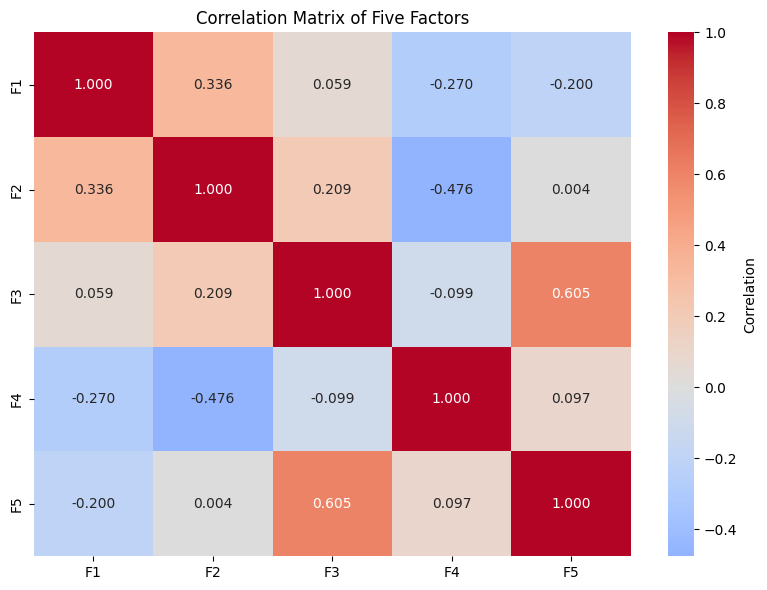

In [ ]:
# Plot the heatmap of the correlations between the 5 factors

# Convert covariance to correlation
std_devs = np.sqrt(np.diag(ohm_f))  # Standard deviations on diagonal
corr_F = ohm_f / np.outer(std_devs, std_devs)  # Correlation matrix

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_F,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            xticklabels=['F1', 'F2', 'F3', 'F4', 'F5'],
            yticklabels=['F1', 'F2', 'F3', 'F4', 'F5'],
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Five Factors')
plt.tight_layout()
plt.show()

**Which pair of factors are most correlated?**

- Most positively correlated: Factor 3 and Factor 5
- Most negatively correlated: Factor 2 and Factor 4
- Greatest magnitude correlation: Factor 3 and Factor 5

# Problem 4

In [ ]:
# B already contains only the 5 factor loadings and is aligned with epsilon
# Combine the loadings, factor returns and idiosyncratic components to obtain
# the total covariance matrix of asset returns: ΩR = BΩF B^T + Ωε

aligned_betas = B.to_numpy()
ohm_r = aligned_betas @ ohm_f @ aligned_betas.T + Omega_epsilon.to_numpy()
ohm_r

array([[4.26659823e-03, 2.62549207e-03, 1.50679323e-03, ...,
        1.92946922e-03, 2.72585508e-03, 4.99477363e-03],
       [2.62549207e-03, 1.78698104e-02, 2.75571984e-03, ...,
        2.88094913e-03, 3.84263405e-05, 8.20372610e-03],
       [1.50679323e-03, 2.75571984e-03, 4.13131158e-03, ...,
        2.88563321e-03, 7.13859502e-04, 3.70774284e-03],
       ...,
       [1.92946922e-03, 2.88094913e-03, 2.88563321e-03, ...,
        5.08968134e-03, 2.66200778e-03, 4.01095926e-03],
       [2.72585508e-03, 3.84263405e-05, 7.13859502e-04, ...,
        2.66200778e-03, 1.56321171e-02, 3.20705420e-03],
       [4.99477363e-03, 8.20372610e-03, 3.70774284e-03, ...,
        4.01095926e-03, 3.20705420e-03, 2.25306689e-02]])

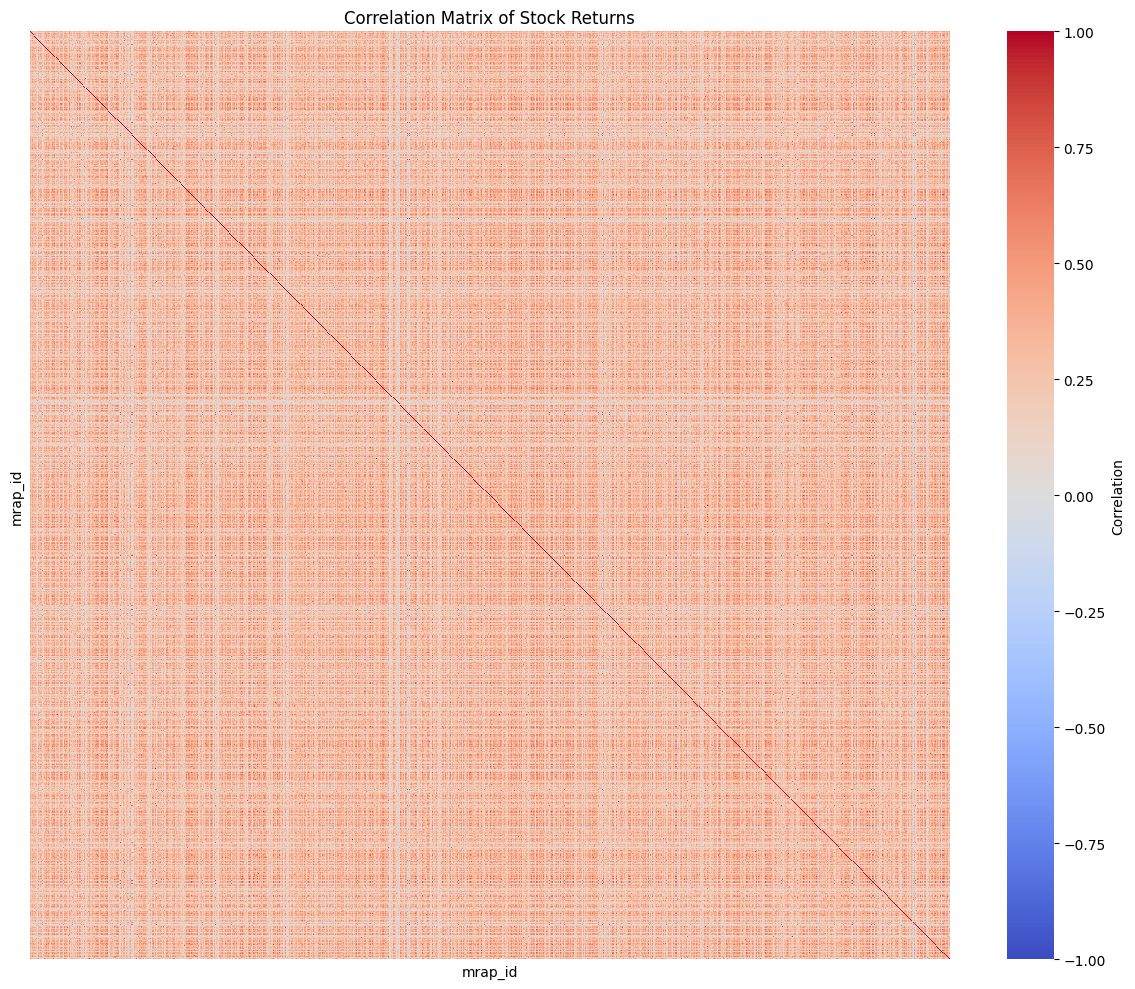

In [ ]:
# Plot the heatmap of the correlation matrix of returns (it will be large)

# Convert covariance to correlation
std_devs_r = np.sqrt(np.diag(ohm_r))
corr_r = ohm_r / np.outer(std_devs_r, std_devs_r)

corr_r = pd.DataFrame(corr_r, index=B.index, columns=B.index)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_r,
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1,
            cbar_kws={'label': 'Correlation'},
            xticklabels=False,
            yticklabels=False)
plt.title('Correlation Matrix of Stock Returns')
plt.tight_layout()
plt.show()

In [ ]:
# Report the estimated correlation between MRAP ID’s 24541 and 91309 (using your constructed ΩR)

correlation_24541_91309 = corr_r.loc[24541, 91309]
print(f"Estimated correlation between MRAP ID 24541 and 91309: {correlation_24541_91309:.4f}")

Estimated correlation between MRAP ID 24541 and 91309: 0.8839


**What errors could have happened in the construction of this covariance matrix? What could be improved?**

- Any stocks that have no days with both factor values and returns have zeros for factor loads and as a result zeros in the covariance. In our case this is only a single stock so it is not a big issue
- Any outliers, either in daily returns or factor loadings, could skew the covariance matrix. Adding regularization to our factor model could reduce the effect of large factor betas, especially if there is collinearity between multiple factors
- The number of sample periods (108) is relatively small, especially considering we are looking across 1000 stocks. Taking a longer duration of samples with a shorter period would increase the amount of data
- We are not adjusting for the risk free returns in our model, or looking at excess returns. This means changes in the risk free rate can create excess covariance that is explained by risk free returns. To address this, we could predict and evaluate excess returns instead of returns

# Problem 5

We could forecast January 2041 returns by using our factor beta model on expected factors:

1) Forecast factor values for the month: We would need to determine an appropriate way of modeling each factor using historical data. The right way to do this depends heavily on what the factor is and how we think we can reasonably model it. For example, are recent months predictive of the next month value of the factor? Is the safest way to estimate the factor by using a historical mean?
2) Use our model (factor betas based on historic data) to predict returns for each stock, in the same way that we estimated historic returns above
3) Additionally, we could choose to expand our model to include alpha (average returns not explained by factors), to attempt to create more accurate estimates

# Problem 6

**Key assumptions:**

1) Optimizing for a single period horizon will lead to long-term optimal outcomes
2) Returns are normally distributed (ignoring skewness/kurtosis/tail risk)
3) Returns are stationary (estimated means/variances from historical data will continue)
4) It is safe to ignore estimation error (i.e. our estimates are good enough)
5) Investors are rational and risk-averse (prefer higher returns for the same risk and lower risk for the same return)

# Problem 7

estimates.xlsx

mrap_id – identifier

naics – North American Industry Classification System Code

price – average of bid-ask price at close

ret – total return if money invested in security at period t-1

shrout – shares outstanding in 000’s

pred – predicted return

In [ ]:
estimates_df = pd.read_excel("estimates.xlsx")
estimates_df

,mrap_id,naics,price,ret,shrout,pred
0,40101,541512,111.68000,-0.000179,2748922,-0.023162
1,70101,511210,413.64001,0.042281,7430436,0.019637
2,83101,523940,113.35000,0.045182,223657,0.006730
3,54101,336412,198.73000,-0.012113,652182,-0.035248
4,201,325414,193.99001,0.024234,55771,0.206953
...,...,...,...,...,...,...
995,65339,511210,185.16000,0.007399,36974,-0.003727
996,96339,561110,14.05000,0.372070,420280,0.156123
997,47339,524127,58.41000,-0.032146,103100,0.007103
998,92439,518210,192.00000,0.047321,105582,-0.006901


## 7.a

In [ ]:
### Revising the matrices to ensure I have properly cleaned them
aligned_estimates = estimates_df.set_index('mrap_id').reindex(B.index)
print("Missing pred values:", aligned_estimates['pred'].isna().sum())
print("Missing ret values:", aligned_estimates['ret'].isna().sum())

print("NaNs in mu:", np.isnan(mu).sum())
print("Infs in mu:", np.isinf(mu).sum())

print("NaNs in ohm_r_psd:", np.isnan(ohm_r_psd).sum())
print("Infs in ohm_r_psd:", np.isinf(ohm_r_psd).sum())

print("NaNs in ohm_r:", np.isnan(ohm_r).sum())
print("Infs in ohm_r:", np.isinf(ohm_r).sum())

Missing pred values: 0
Missing ret values: 0
NaNs in mu: 0
Infs in mu: 0
NaNs in ohm_r_psd: 0
Infs in ohm_r_psd: 0
NaNs in ohm_r: 0
Infs in ohm_r: 0


In [ ]:
# Use the expected returns from estimates.xlsx and the covariance matrix ΩR
# to perform a portfolio optimization with no additional constraints.

# Make ohm_r positive semi-definite using eigenvalue clipping
eigenvalues, eigenvectors = np.linalg.eigh(ohm_r)
eigenvalues_clipped = np.maximum(eigenvalues, 1e-8)
ohm_r_psd = eigenvectors @ np.diag(eigenvalues_clipped) @ eigenvectors.T
ohm_r_psd = 0.5 * (ohm_r_psd + ohm_r_psd.T)

# Align estimates with the cleaned stock universe
aligned_estimates = estimates_df.set_index('mrap_id').reindex(B.index)

# Expected returns vector
mu = aligned_estimates['pred'].values

n = len(mu)

# Decision variable: portfolio weights
w = cp.Variable(n)

# Maximize expected return
objective = cp.Maximize(w.T @ mu)

# Constraints
vol_limit = (0.10 / np.sqrt(12))**2

constraints = [
    cp.sum(w) == 0,  # Dollar neutral
    cp.quad_form(w, cp.psd_wrap(ohm_r_psd)) <= vol_limit
]

# Solve
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS, verbose=True)

# Extract results
weights_7a = w.value
portfolio_return_expected_7a = mu @ weights_7a
portfolio_vol_7a = np.sqrt(weights_7a.T @ ohm_r_psd @ weights_7a)

print(f"Status: {problem.status}")
print(f"Expected Return: {portfolio_return_expected_7a:.4f} ({portfolio_return_expected_7a*12:.2%} annualized)")
print(f"Portfolio Volatility: {portfolio_vol_7a:.4f} ({portfolio_vol_7a*np.sqrt(12):.2%} annualized)")
print(f"Number of long positions: {(weights_7a > 1e-6).sum()}")
print(f"Number of short positions: {(weights_7a < -1e-6).sum()}")

(CVXPY) Apr 24 08:17:54 PM: Your problem has 958 variables, 2 constraints, and 0 parameters.
(CVXPY) Apr 24 08:17:54 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 24 08:17:54 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 24 08:17:54 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 24 08:17:54 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 24 08:17:54 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 24 08:17:54 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 24 08:17:54 PM: Applying reduction FlipObjective
(CVXPY) Apr 24 08:17:54 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 24 08:17:54 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 24 08:17:54 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 24 08:17:54 PM: Applying reduction SCS
(CVXPY) Apr 24 08:17:54 PM: Finished problem compilation (took 6.818e-01 seconds).
(CVXPY) Apr 24 08:17:54 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 959, constraints m: 962
cones: 	  z: primal zero / dual free vars: 1
	  l: linear vars: 1
	  q: soc vars: 960, qsize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 917880, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |   ga

(CVXPY) Apr 24 08:18:38 PM: Problem status: optimal
(CVXPY) Apr 24 08:18:38 PM: Optimal value: 1.353e+03
(CVXPY) Apr 24 08:18:38 PM: Compilation took 6.818e-01 seconds
(CVXPY) Apr 24 08:18:38 PM: Solver (including time spent in interface) took 4.415e+01 seconds


  8725| 6.96e-06  2.56e-06  2.09e-04 -1.35e+03  3.18e+01  4.41e+01 
------------------------------------------------------------------
status:  solved
timings: total: 4.41e+01s = setup: 1.28e+00s + solve: 4.29e+01s
	 lin-sys: 3.70e+01s, cones: 7.24e-02s, accel: 2.45e-02s
------------------------------------------------------------------
objective = -1353.159799
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
Expected Return: 1353.1599 (1623791.88% annualized)
Portfolio Volatility: 0.0289 (10.00% annualized)
Number of long positions: 406
Number of short positions: 552


In [ ]:
# Store weights with stock labels
weights_7a = pd.Series(weights_7a, index=B.index)

# Realized return for evaluation
realized_returns_7a = aligned_estimates['ret']
portfolio_return_realized_7a = float(weights_7a @ realized_returns_7a)

print(f"Realized Return: {portfolio_return_realized_7a:.4f} ({portfolio_return_realized_7a*12:.2%} annualized)")

print("Top 10 long positions:")
display(weights_7a.sort_values(ascending=False).head(10))

print("Top 10 short positions:")
display(weights_7a.sort_values().head(10))

Realized Return: 30.6881 (36825.76% annualized)
Top 10 long positions:


,0
mrap_id,
34029,75.861073
62329,66.388942
90811,52.159066
96748,48.104700
8809,43.867720
92601,43.543036
33219,43.191751
62032,40.881371
64488,40.860154


Top 10 short positions:


,0
mrap_id,
92946,-46.326464
771,-34.591915
23408,-32.510341
71558,-29.701889
32265,-29.465608
12541,-26.504739
94434,-24.740894
82891,-22.494850
88268,-22.008414


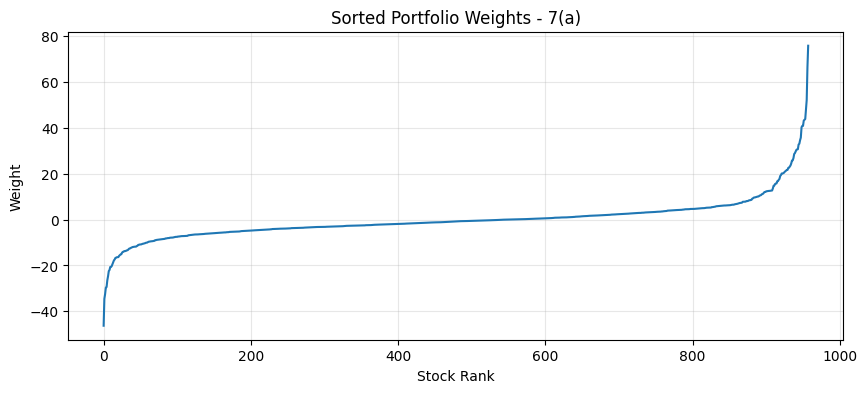

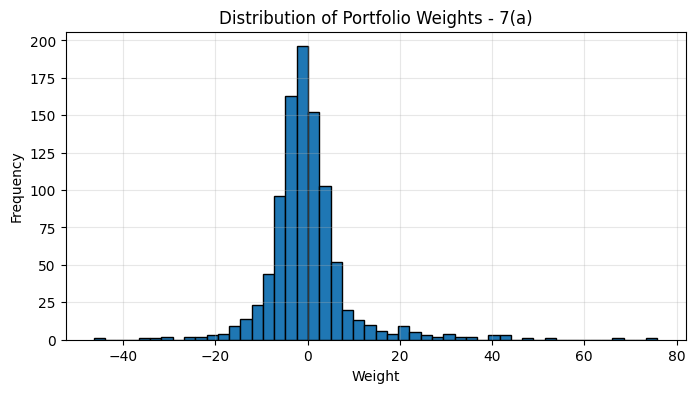

In [ ]:
# Sorted portfolio weights
sorted_weights_7a = weights_7a.sort_values()

plt.figure(figsize=(10, 4))
plt.plot(sorted_weights_7a.values)
plt.title("Sorted Portfolio Weights - 7(a)")
plt.xlabel("Stock Rank")
plt.ylabel("Weight")
plt.grid(True, alpha=0.3)
plt.show()

# Distribution of portfolio weights
plt.figure(figsize=(8, 4))
plt.hist(weights_7a.values, bins=50, edgecolor='black')
plt.title("Distribution of Portfolio Weights - 7(a)")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
factor_exposure_7a = weights_7a @ B
print("Factor exposures:")
display(factor_exposure_7a)

Factor exposures:


,0
factor_1,4.257547
factor_2,-10.153826
factor_3,-6.620609
factor_4,-22.535238
factor_5,12.404191


In [ ]:
sector_list = ['52', '33', '32', '51', '54', '53', '22', '21', '56', '31']

sector_codes = aligned_estimates['naics'].astype(str).str[:2]

sector_exposure_7a = pd.Series({
    s: weights_7a[sector_codes == s].sum()
    for s in sector_list
})

print("Sector exposures:")
display(sector_exposure_7a)

Sector exposures:


,0
52,80.249685
33,55.156059
32,37.712886
51,-94.623125
54,15.305742
53,-11.445805
22,46.439187
21,-33.393585
56,101.106490
31,-12.142432


In [ ]:
gross_exposure_7a = np.abs(weights_7a).sum()
net_exposure_7a = weights_7a.sum()

print(f"Gross Exposure: {gross_exposure_7a:.4f}")
print(f"Net Exposure: {net_exposure_7a:.4f}")

Gross Exposure: 5386.1288
Net Exposure: -0.0000


**In addition to the above mentioned measures, do you notice any patterns or potential issues in the results?**

*   The optimizer gives very extreme and concentrated solutions. Even though it stays within the constraints, it creates large swings in the portfolio weights in order to keep net exposure at 0 and maximize expected return.
*   Complementing the previous point, we can also see from the factor and sector exposures that the portfolio is loading heavily on a small set of risks. It shifts weight across sectors with basically no limitations, which would imply trading patterns that are not very realistic or easy to implement in practice.
*   Another issue is that both the expected and realized returns are economically unrealistic in magnitude, which suggests the optimizer is overreacting to small differences in the estimated returns and covariance matrix.
*   Overall, the results suggest that while the optimization is mathematically valid, it is not realistic as an investable portfolio and shows why additional constraints are needed in the next parts.







##7.b

In [ ]:
# Shared prep for 7(b)

portfolio_size = 100_000_000

# Average historical monthly dollar volume
# vol is in 00's, so shares traded = vol * 100
avg_dollar_vol = (
    data_df.assign(dollar_vol=data_df['vol'] * 100 * data_df['price'])
    .groupby('mrap_id')['dollar_vol']
    .mean()
    .reindex(B.index)
    .fillna(0)
)

# Volume-based max weight: at most 2% of avg monthly dollar volume
volume_cap = (0.02 * avg_dollar_vol) / portfolio_size

# Reuse cleaned covariance and expected returns
aligned_estimates = estimates_df.set_index('mrap_id').reindex(B.index)
mu = aligned_estimates['pred'].values
realized = aligned_estimates['ret'].values

# PSD covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(ohm_r)
eigenvalues_clipped = np.maximum(eigenvalues, 1e-8)
ohm_r_psd = eigenvectors @ np.diag(eigenvalues_clipped) @ eigenvectors.T
ohm_r_psd = 0.5 * (ohm_r_psd + ohm_r_psd.T)

vol_limit = (0.10 / np.sqrt(12))**2
n = len(B.index)

##7.b (i)

In [ ]:
# Problem 7(b)(i): 1% position cap

position_cap = 0.01
final_cap_7b1 = np.minimum(position_cap, volume_cap.values)

w = cp.Variable(n)

objective = cp.Maximize(w.T @ mu)

constraints = [
    cp.sum(w) == 0,
    cp.quad_form(w, cp.psd_wrap(ohm_r_psd)) <= vol_limit,
    w <= final_cap_7b1,
    w >= -final_cap_7b1
]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS, verbose=True)

weights_7b1 = pd.Series(w.value, index=B.index)

expected_return_7b1 = float(weights_7b1.values @ mu)
realized_return_7b1 = float(weights_7b1.values @ realized)
portfolio_vol_7b1 = float(np.sqrt(weights_7b1.values @ ohm_r_psd @ weights_7b1.values))
gross_exposure_7b1 = float(np.abs(weights_7b1).sum())

print(f"Status: {problem.status}")
print(f"Expected Return: {expected_return_7b1:.4f} ({expected_return_7b1*12:.2%} annualized)")
print(f"Realized Return: {realized_return_7b1:.4f} ({realized_return_7b1*12:.2%} annualized)")
print(f"Portfolio Volatility: {portfolio_vol_7b1:.4f} ({portfolio_vol_7b1*np.sqrt(12):.2%} annualized)")
print(f"Gross Exposure: {gross_exposure_7b1:.4f}")
print(f"Net Exposure: {weights_7b1.sum():.4f}")
print(f"Number of long positions: {(weights_7b1 > 1e-6).sum()}")
print(f"Number of short positions: {(weights_7b1 < -1e-6).sum()}")

(CVXPY) Apr 24 08:37:40 PM: Your problem has 958 variables, 1918 constraints, and 0 parameters.
(CVXPY) Apr 24 08:37:40 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 24 08:37:40 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 24 08:37:40 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 24 08:37:40 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 24 08:37:40 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 24 08:37:40 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 24 08:37:40 PM: Applying reduction FlipObjective
(CVXPY) Apr 24 08:37:40 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 24 08:37:41 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 24 08:37:41 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 24 08:37:41 PM: Applying reduction SCS
(CVXPY) Apr 24 08:37:41 PM: Finished problem compilation (took 1.745e+00 seconds).
(CVXPY) Apr 24 08:37:41 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 959, constraints m: 2878
cones: 	  z: primal zero / dual free vars: 1
	  l: linear vars: 1917
	  q: soc vars: 960, qsize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 919796, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res | 

(CVXPY) Apr 24 08:38:03 PM: Problem status: optimal
(CVXPY) Apr 24 08:38:03 PM: Optimal value: 8.095e-01
(CVXPY) Apr 24 08:38:03 PM: Compilation took 1.745e+00 seconds
(CVXPY) Apr 24 08:38:03 PM: Solver (including time spent in interface) took 2.134e+01 seconds


  3850| 3.54e-07  1.51e-05  1.76e-06 -8.10e-01  2.89e+01  2.13e+01 
------------------------------------------------------------------
status:  solved
timings: total: 2.13e+01s = setup: 1.29e+00s + solve: 2.00e+01s
	 lin-sys: 1.49e+01s, cones: 4.90e-02s, accel: 1.64e-02s
------------------------------------------------------------------
objective = -0.809512
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
Expected Return: 0.8095 (971.41% annualized)
Realized Return: 0.1298 (155.72% annualized)
Portfolio Volatility: 0.0289 (10.00% annualized)
Gross Exposure: 9.5068
Net Exposure: 0.0000
Number of long positions: 479
Number of short positions: 479




*   The 1% position cap and volume constraint make the portfolio much more realistic than in 7(a). The optimizer can no longer place extreme weights in a few names, so the solution is much more balanced.
*   A clear improvement is that gross exposure falls from 5386.13 to 9.51, while the portfolio still stays dollar neutral and uses the full volatility limit. This means the optimizer is no longer relying on huge offsetting long and short positions.
*   The portfolio is also more diversified, with 479 longs and 479 shorts, which makes it more stable and easier to implement.
*   Overall, this looks much more reasonable than the unconstrained case. The expected return is lower, but the portfolio is far more practical.





##7.b (ii)

In [ ]:
# Problem 7(b)(ii): 50 bps position cap

position_cap = 0.005
final_cap_7b2 = np.minimum(position_cap, volume_cap.values)

w = cp.Variable(n)

objective = cp.Maximize(w.T @ mu)

constraints = [
    cp.sum(w) == 0,
    cp.quad_form(w, cp.psd_wrap(ohm_r_psd)) <= vol_limit,
    w <= final_cap_7b2,
    w >= -final_cap_7b2
]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS, verbose=True)

weights_7b2 = pd.Series(w.value, index=B.index)

expected_return_7b2 = float(weights_7b2.values @ mu)
realized_return_7b2 = float(weights_7b2.values @ realized)
portfolio_vol_7b2 = float(np.sqrt(weights_7b2.values @ ohm_r_psd @ weights_7b2.values))
gross_exposure_7b2 = float(np.abs(weights_7b2).sum())

print(f"Status: {problem.status}")
print(f"Expected Return: {expected_return_7b2:.4f} ({expected_return_7b2*12:.2%} annualized)")
print(f"Realized Return: {realized_return_7b2:.4f} ({realized_return_7b2*12:.2%} annualized)")
print(f"Portfolio Volatility: {portfolio_vol_7b2:.4f} ({portfolio_vol_7b2*np.sqrt(12):.2%} annualized)")
print(f"Gross Exposure: {gross_exposure_7b2:.4f}")
print(f"Net Exposure: {weights_7b2.sum():.4f}")
print(f"Number of long positions: {(weights_7b2 > 1e-6).sum()}")
print(f"Number of short positions: {(weights_7b2 < -1e-6).sum()}")

(CVXPY) Apr 24 10:18:24 PM: Your problem has 958 variables, 1918 constraints, and 0 parameters.
(CVXPY) Apr 24 10:18:24 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 24 10:18:24 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 24 10:18:24 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 24 10:18:24 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 24 10:18:24 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 24 10:18:24 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 24 10:18:24 PM: Applying reduction FlipObjective
(CVXPY) Apr 24 10:18:24 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 24 10:18:24 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 24 10:18:24 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 24 10:18:25 PM: Applying reduction SCS
(CVXPY) Apr 24 10:18:25 PM: Finished problem compilation (took 7.357e-01 seconds).
(CVXPY) Apr 24 10:18:25 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 959, constraints m: 2878
cones: 	  z: primal zero / dual free vars: 1
	  l: linear vars: 1917
	  q: soc vars: 960, qsize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 919796, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res | 

(CVXPY) Apr 24 10:18:42 PM: Problem status: optimal
(CVXPY) Apr 24 10:18:42 PM: Optimal value: 4.065e-01
(CVXPY) Apr 24 10:18:42 PM: Compilation took 7.357e-01 seconds
(CVXPY) Apr 24 10:18:42 PM: Solver (including time spent in interface) took 1.688e+01 seconds


  1450| 1.64e-06  8.56e-06  1.10e-05 -4.07e-01  1.05e+00  1.69e+01 
------------------------------------------------------------------
status:  solved
timings: total: 1.69e+01s = setup: 2.56e+00s + solve: 1.43e+01s
	 lin-sys: 7.63e+00s, cones: 2.74e-02s, accel: 6.30e-03s
------------------------------------------------------------------
objective = -0.406539
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
Expected Return: 0.4065 (487.84% annualized)
Realized Return: 0.0679 (81.44% annualized)
Portfolio Volatility: 0.0156 (5.41% annualized)
Gross Exposure: 4.7844
Net Exposure: 0.0000
Number of long positions: 479
Number of short positions: 479




*   Tightening the cap to 50 bps makes the portfolio even more conservative. Relative to 7(b)(i), both the expected return and realized return fall, which is what we would expect once the optimizer has less flexibility.
*   Gross exposure also drops further, from 9.51 to 4.78, so the portfolio becomes even more realistic and easier to implement.
*   One important thing here is that the portfolio volatility is now only 5.41% annualized, well below the 10% cap. This suggests that with the tighter position and volume constraints, the optimizer cannot take enough risk to fully use the volatility budget.
*   Overall, this case is more conservative and more realistic than 7(b)(i), but the tradeoff is that it gives up a meaningful amount of return and does not fully use the allowed risk.



##7.b (iii)

In [ ]:
# Problem 7(b)(iii): 10% position cap

position_cap = 0.10
final_cap_7b3 = np.minimum(position_cap, volume_cap.values)

w = cp.Variable(n)

objective = cp.Maximize(w.T @ mu)

constraints = [
    cp.sum(w) == 0,
    cp.quad_form(w, cp.psd_wrap(ohm_r_psd)) <= vol_limit,
    w <= final_cap_7b3,
    w >= -final_cap_7b3
]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS, verbose=True)

weights_7b3 = pd.Series(w.value, index=B.index)

expected_return_7b3 = float(weights_7b3.values @ mu)
realized_return_7b3 = float(weights_7b3.values @ realized)
portfolio_vol_7b3 = float(np.sqrt(weights_7b3.values @ ohm_r_psd @ weights_7b3.values))
gross_exposure_7b3 = float(np.abs(weights_7b3).sum())

print(f"Status: {problem.status}")
print(f"Expected Return: {expected_return_7b3:.4f} ({expected_return_7b3*12:.2%} annualized)")
print(f"Realized Return: {realized_return_7b3:.4f} ({realized_return_7b3*12:.2%} annualized)")
print(f"Portfolio Volatility: {portfolio_vol_7b3:.4f} ({portfolio_vol_7b3*np.sqrt(12):.2%} annualized)")
print(f"Gross Exposure: {gross_exposure_7b3:.4f}")
print(f"Net Exposure: {weights_7b3.sum():.4f}")
print(f"Number of long positions: {(weights_7b3 > 1e-6).sum()}")
print(f"Number of short positions: {(weights_7b3 < -1e-6).sum()}")

(CVXPY) Apr 24 08:38:55 PM: Your problem has 958 variables, 1918 constraints, and 0 parameters.
(CVXPY) Apr 24 08:38:55 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 24 08:38:55 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 24 08:38:55 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 24 08:38:55 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 24 08:38:55 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 24 08:38:55 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 24 08:38:55 PM: Applying reduction FlipObjective
(CVXPY) Apr 24 08:38:55 PM: Applying reduction Dcp2Cone
(CVXPY) Apr 24 08:38:55 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 24 08:38:55 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 24 08:38:55 PM: Applying reduction SCS
(CVXPY) Apr 24 08:38:55 PM: Finished problem compilation (took 5.080e-01 seconds).
(CVXPY) Apr 24 08:38:55 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 959, constraints m: 2878
cones: 	  z: primal zero / dual free vars: 1
	  l: linear vars: 1917
	  q: soc vars: 960, qsize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 919796, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res | 

(CVXPY) Apr 24 08:40:30 PM: Problem status: optimal
(CVXPY) Apr 24 08:40:30 PM: Optimal value: 6.639e+00
(CVXPY) Apr 24 08:40:30 PM: Compilation took 5.080e-01 seconds
(CVXPY) Apr 24 08:40:30 PM: Solver (including time spent in interface) took 9.496e+01 seconds


 22550| 1.03e-06  7.27e-06  7.06e-06 -6.64e+00  2.06e+00  9.49e+01 
------------------------------------------------------------------
status:  solved
timings: total: 9.49e+01s = setup: 1.15e+00s + solve: 9.38e+01s
	 lin-sys: 8.94e+01s, cones: 2.93e-01s, accel: 1.02e-01s
------------------------------------------------------------------
objective = -6.639247
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
Expected Return: 6.6393 (7967.10% annualized)
Realized Return: 0.7255 (870.62% annualized)
Portfolio Volatility: 0.0289 (10.00% annualized)
Gross Exposure: 78.9023
Net Exposure: -0.0000
Number of long positions: 474
Number of short positions: 484




*   With the 10% cap, the portfolio becomes much less constrained than in the 1% and 50 bps cases, so the optimizer starts moving back toward a more aggressive solution. This is clear from the jump in gross exposure to 78.90, which is much higher than in the tighter-cap cases
*   The portfolio again uses the full 10% annualized volatility limit, so in this case the looser position cap gives the optimizer enough flexibility to fully use the risk budget.
*   Compared to 7(b)(i) and 7(b)(ii), both the expected return and realized return increase a lot, but the tradeoff is that the portfolio becomes much more aggressive and concentrated.
*   Overall, this case sits between the tightly constrained portfolios and the unconstrained one: it is still far more controlled than 7(a), but clearly less conservative than the 1% and 50 bps cases.

##7.c
**Explain in words how you would adjust the optimization to achieve an F1 neutral port-
folio (the portfolio is not exposed to changes in the first factor).**

*   To make the portfolio F1 neutral, we add a linear constraint requiring the weighted sum of stock exposures to factor 1 to equal zero. This removes the portfolio’s net sensitivity to movements in the first factor, so the optimizer has to look for return while avoiding that source of common risk.
*   Relative to the previous cases, we would expect some reduction in expected return, since we are removing one direction the optimizer may have used to generate return.






In [ ]:
# Problem 7(c): F1 neutrality

# Volume-based cap from 7(b)
final_cap_7c = volume_cap.values

f1_loadings = B['factor_1'].values

w = cp.Variable(n)

objective = cp.Maximize(w.T @ mu)

constraints = [
    cp.sum(w) == 0,                                  # dollar neutral
    cp.quad_form(w, cp.psd_wrap(ohm_r_psd)) <= vol_limit,
    w <= final_cap_7c,
    w >= -final_cap_7c,
    w.T @ f1_loadings == 0                           # F1 neutral
]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS, verbose=True)

weights_7c = pd.Series(w.value, index=B.index)

expected_return_7c = float(weights_7c.values @ mu)
realized_return_7c = float(weights_7c.values @ realized)
portfolio_vol_7c = float(np.sqrt(weights_7c.values @ ohm_r_psd @ weights_7c.values))
gross_exposure_7c = float(np.abs(weights_7c).sum())

print(f"Status: {problem.status}")
print(f"Expected Return: {expected_return_7c:.4f} ({expected_return_7c*12:.2%} annualized)")
print(f"Realized Return: {realized_return_7c:.4f} ({realized_return_7c*12:.2%} annualized)")
print(f"Portfolio Volatility: {portfolio_vol_7c:.4f} ({portfolio_vol_7c*np.sqrt(12):.2%} annualized)")
print(f"Gross Exposure: {gross_exposure_7c:.4f}")
print(f"Net Exposure: {weights_7c.sum():.4f}")
print(f"F1 Exposure: {float(weights_7c @ B['factor_1']):.8f}")
print(f"Number of long positions: {(weights_7c > 1e-6).sum()}")
print(f"Number of short positions: {(weights_7c < -1e-6).sum()}")

(CVXPY) Apr 24 10:30:21 PM: Your problem has 958 variables, 1919 constraints, and 0 parameters.
(CVXPY) Apr 24 10:30:21 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 24 10:30:21 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 24 10:30:21 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 24 10:30:21 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 24 10:30:21 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 24 10:30:21 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 24 10:30:21 PM: Applying reduction FlipObjective
(CVXPY) Apr 24 10:30:21 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 24 10:30:22 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 24 10:30:22 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 24 10:30:23 PM: Applying reduction SCS
(CVXPY) Apr 24 10:30:23 PM: Finished problem compilation (took 1.869e+00 seconds).
(CVXPY) Apr 24 10:30:23 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 959, constraints m: 2879
cones: 	  z: primal zero / dual free vars: 2
	  l: linear vars: 1917
	  q: soc vars: 960, qsize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 920754, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res | 

/usr/local/lib/python3.12/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
(CVXPY) Apr 24 10:37:43 PM: Problem status: optimal_inaccurate
(CVXPY) Apr 24 10:37:43 PM: Optimal value: 3.699e+01
(CVXPY) Apr 24 10:37:43 PM: Compilation took 1.869e+00 seconds
(CVXPY) Apr 24 10:37:43 PM: Solver (including time spent in interface) took 4.401e+02 seconds


100000| 1.84e-05  5.68e-07  3.36e-03 -3.70e+01  1.00e-01  4.40e+02 
------------------------------------------------------------------
status:  solved (inaccurate - reached max_iters)
timings: total: 4.40e+02s = setup: 1.45e+00s + solve: 4.39e+02s
	 lin-sys: 4.27e+02s, cones: 1.25e+00s, accel: 5.41e-01s
------------------------------------------------------------------
objective = -36.989256 (inaccurate)
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal_inaccurate
Expected Return: 36.9909 (44389.12% annualized)
Realized Return: 4.1985 (5038.19% annualized)
Portfolio Volatility: 0.0292 (10.11% annualized)
Gross Exposure: 433.5943
Net Exposure: -0.0000
F1 Exposure: 0.00000003
Number of long positions: 474
Number of shor

In [ ]:
factor_exposure_7c = weights_7c @ B
print("Factor exposures:")
display(factor_exposure_7c)

sector_codes = aligned_estimates['naics'].astype(str).str[:2]
sector_list = ['52', '33', '32', '51', '54', '53', '22', '21', '56', '31']

sector_exposure_7c = pd.Series({
    s: weights_7c[sector_codes == s].sum()
    for s in sector_list
})

print("Sector exposures:")
display(sector_exposure_7c)

Factor exposures:


,0
factor_1,2.841266e-08
factor_2,-4.606544e-01
factor_3,2.040997e-01
factor_4,-6.040201e-01
factor_5,-3.626609e-01


Sector exposures:


,0
52,4.915943
33,-7.027226
32,12.774241
51,-13.706321
54,-2.272226
53,0.411052
22,-1.213316
21,0.810188
56,3.500197
31,-1.040051


The F1 neutrality constraint worked, since the exposure to factor 1 is essentially zero. At the same time, the portfolio still keeps exposure to the other factors, especially factors 2 and 4, and it also still has noticeable sector tilts, particularly long sector 32 and short sector 51. So overall, the optimizer is no longer using factor 1 to generate return, but it is still finding return through other factor and sector exposures.

## 7.d

In [ ]:
# Problem 7(d): Sector neutrality

sector_list = ['52', '33', '32', '51', '54', '53', '22', '21', '56', '31']

sector_codes = aligned_estimates['naics'].astype(str).str[:2]

sector_matrix = pd.DataFrame({
    s: (sector_codes == s).astype(float)
    for s in sector_list
}, index=B.index)

final_cap_7d = volume_cap.values

w = cp.Variable(n)

objective = cp.Maximize(w.T @ mu)

constraints = [
    cp.sum(w) == 0,
    cp.quad_form(w, cp.psd_wrap(ohm_r_psd)) <= vol_limit,
    w <= final_cap_7d,
    w >= -final_cap_7d
]

# Sector-neutral constraints
for s in sector_list:
    constraints.append(w.T @ sector_matrix[s].values == 0)

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS, verbose=True)

weights_7d = pd.Series(w.value, index=B.index)

expected_return_7d = float(weights_7d.values @ mu)
realized_return_7d = float(weights_7d.values @ realized)
portfolio_vol_7d = float(np.sqrt(weights_7d.values @ ohm_r_psd @ weights_7d.values))
gross_exposure_7d = float(np.abs(weights_7d).sum())

print(f"Status: {problem.status}")
print(f"Expected Return: {expected_return_7d:.4f} ({expected_return_7d*12:.2%} annualized)")
print(f"Realized Return: {realized_return_7d:.4f} ({realized_return_7d*12:.2%} annualized)")
print(f"Portfolio Volatility: {portfolio_vol_7d:.4f} ({portfolio_vol_7d*np.sqrt(12):.2%} annualized)")
print(f"Gross Exposure: {gross_exposure_7d:.4f}")
print(f"Net Exposure: {weights_7d.sum():.4f}")
print(f"Number of long positions: {(weights_7d > 1e-6).sum()}")
print(f"Number of short positions: {(weights_7d < -1e-6).sum()}")

(CVXPY) Apr 24 11:17:05 PM: Your problem has 958 variables, 1928 constraints, and 0 parameters.
(CVXPY) Apr 24 11:17:05 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 24 11:17:05 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 24 11:17:05 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 24 11:17:05 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 24 11:17:05 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 24 11:17:05 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 24 11:17:05 PM: Applying reduction FlipObjective
(CVXPY) Apr 24 11:17:05 PM: Applying reduction Dcp2Cone
(CVXPY) Apr 24 11:17:05 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 24 11:17:05 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 24 11:17:06 PM: Applying reduction SCS
(CVXPY) Apr 24 11:17:06 PM: Finished problem compilation (took 5.301e-01 seconds).
(CVXPY) Apr 24 11:17:06 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 959, constraints m: 2888
cones: 	  z: primal zero / dual free vars: 11
	  l: linear vars: 1917
	  q: soc vars: 960, qsize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 920557, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |

(CVXPY) Apr 24 11:23:30 PM: Problem status: optimal
(CVXPY) Apr 24 11:23:30 PM: Optimal value: 3.622e+01
(CVXPY) Apr 24 11:23:30 PM: Compilation took 5.301e-01 seconds
(CVXPY) Apr 24 11:23:30 PM: Solver (including time spent in interface) took 3.843e+02 seconds


 84725| 3.38e-06  1.11e-06  2.74e-04 -3.62e+01  1.00e-01  3.84e+02 
------------------------------------------------------------------
status:  solved
timings: total: 3.84e+02s = setup: 1.58e+00s + solve: 3.83e+02s
	 lin-sys: 3.73e+02s, cones: 1.07e+00s, accel: 4.52e-01s
------------------------------------------------------------------
objective = -36.216075
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
Expected Return: 36.2162 (43459.45% annualized)
Realized Return: 3.3533 (4023.93% annualized)
Portfolio Volatility: 0.0289 (10.01% annualized)
Gross Exposure: 426.1851
Net Exposure: 0.0000
Number of long positions: 462
Number of short positions: 496


In [ ]:
sector_exposure_7d = pd.Series({
    s: weights_7d[sector_codes == s].sum()
    for s in sector_list
})

print("Sector exposures:")
display(sector_exposure_7d)

factor_exposure_7d = weights_7d @ B
print("Factor exposures:")
display(factor_exposure_7d)

Sector exposures:


,0
52,-2.697583e-09
33,9.056214e-10
32,-1.383242e-09
51,-1.819513e-09
54,6.685167e-10
53,-8.760687e-10
22,-5.531382e-10
21,2.899393e-09
56,1.647092e-09
31,-3.223102e-09


Factor exposures:


,0
factor_1,-0.134950
factor_2,-0.296154
factor_3,0.405681
factor_4,-0.544008
factor_5,-0.772042


**Implementation**
For the implementation, our idea was to keep all stocks in the investable universe, but remove the portfolio’s net exposure to the selected sectors. We first used the first two digits of each stock’s NAICS code to assign it to one of the sectors {52,33,32,51,54,53,22,21,56,31}. Then, instead of excluding those stocks, we created one constraint per sector so that the sum of portfolio weights within each sector equals zero. This way, the optimizer can still choose names inside those sectors, but it cannot generate return simply by taking a net long or net short sector position. We kept the same dollar-neutral, volatility, and trading constraints from the earlier parts, and only added these sector-neutrality constraints on top.

**Discussion**
The results show that the sector-neutrality constraint worked very well, since all the sector exposures are essentially zero up to numerical error. This means the optimizer is no longer relying on sector tilts to generate return. At the same time, the portfolio still has meaningful exposures to some of the common factors, especially factors 3, 4, and 5, so the return is now coming more from factor bets than from sector bets. Overall, this gives us a portfolio that is much more controlled from a sector-risk perspective while still allowing the optimizer to allocate across stocks within each sector.

##7.e

##7.e (i)

For e(i), we modified the optimization so that the portfolio is neutral to all five factors and also neutral to the selected sector buckets. In order to do this, we kept the same setup as before and added one constraint for each factor and one for each sector, forcing the weighted exposure to each of them to equal zero. So the optimizer can still choose individual stocks, but it can no longer generate return by taking net bets on factor or sector exposures, which is exactly what this part is asking for.

Based on the results, the implementation worked well. All factor exposures are basically zero and all sector exposures are also essentially zero, just with very small numerical error from the solver. That means the portfolio is doing what we wanted: it is no longer relying on common factor bets or sector tilts, and whatever return is left has to come more from stock-specific positioning. Overall, this gives a much cleaner portfolio from a risk exposure point of view, but it also makes the optimization more restrictive since we are removing many of the directions the optimizer was using in the earlier parts.

In [ ]:
# Problem 7(e)(i): Neutrality to all factors and sectors

final_cap_7e1 = volume_cap.values

w = cp.Variable(n)

objective = cp.Maximize(w.T @ mu)

constraints = [
    cp.sum(w) == 0,
    cp.quad_form(w, cp.psd_wrap(ohm_r_psd)) <= vol_limit,
    w <= final_cap_7e1,
    w >= -final_cap_7e1
]

# Neutral to all 5 factors
for f in ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']:
    constraints.append(w.T @ B[f].values == 0)

# Neutral to all selected sectors
for s in sector_list:
    constraints.append(w.T @ sector_matrix[s].values == 0)

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS, verbose=True)

weights_7e1 = pd.Series(w.value, index=B.index)

expected_return_7e1 = float(weights_7e1.values @ mu)
realized_return_7e1 = float(weights_7e1.values @ realized)
portfolio_vol_7e1 = float(np.sqrt(weights_7e1.values @ ohm_r_psd @ weights_7e1.values))
gross_exposure_7e1 = float(np.abs(weights_7e1).sum())

print(f"Status: {problem.status}")
print(f"Expected Return: {expected_return_7e1:.4f} ({expected_return_7e1*12:.2%} annualized)")
print(f"Realized Return: {realized_return_7e1:.4f} ({realized_return_7e1*12:.2%} annualized)")
print(f"Portfolio Volatility: {portfolio_vol_7e1:.4f} ({portfolio_vol_7e1*np.sqrt(12):.2%} annualized)")
print(f"Gross Exposure: {gross_exposure_7e1:.4f}")
print(f"Net Exposure: {weights_7e1.sum():.4f}")

(CVXPY) Apr 24 11:41:31 PM: Your problem has 958 variables, 1933 constraints, and 0 parameters.
(CVXPY) Apr 24 11:41:31 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 24 11:41:31 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 24 11:41:31 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 24 11:41:31 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 24 11:41:31 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 24 11:41:31 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 24 11:41:31 PM: Applying reduction FlipObjective
(CVXPY) Apr 24 11:41:31 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 24 11:41:31 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 24 11:41:31 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 24 11:41:32 PM: Applying reduction SCS
(CVXPY) Apr 24 11:41:32 PM: Finished problem compilation (took 1.074e+00 seconds).
(CVXPY) Apr 24 11:41:32 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 959, constraints m: 2893
cones: 	  z: primal zero / dual free vars: 16
	  l: linear vars: 1917
	  q: soc vars: 960, qsize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 925347, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |

(CVXPY) Apr 24 11:48:18 PM: Problem status: optimal
(CVXPY) Apr 24 11:48:18 PM: Optimal value: 3.620e+01
(CVXPY) Apr 24 11:48:18 PM: Compilation took 1.074e+00 seconds
(CVXPY) Apr 24 11:48:18 PM: Solver (including time spent in interface) took 4.062e+02 seconds


 84625| 3.15e-06  1.63e-06  1.74e-05 -3.62e+01  1.00e-01  4.06e+02 
------------------------------------------------------------------
status:  solved
timings: total: 4.06e+02s = setup: 1.37e+00s + solve: 4.05e+02s
	 lin-sys: 3.95e+02s, cones: 1.07e+00s, accel: 4.57e-01s
------------------------------------------------------------------
objective = -36.200590
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
Expected Return: 36.2006 (43440.70% annualized)
Realized Return: 3.4147 (4097.59% annualized)
Portfolio Volatility: 0.0289 (10.00% annualized)
Gross Exposure: 428.1199
Net Exposure: 0.0000


In [ ]:
factor_exposure_7e1 = weights_7e1 @ B
print("Factor exposures:")
display(factor_exposure_7e1)

sector_exposure_7e1 = pd.Series({
    s: weights_7e1[sector_codes == s].sum()
    for s in sector_list
})
print("Sector exposures:")
display(sector_exposure_7e1)

Factor exposures:


,0
factor_1,-2.864818e-08
factor_2,1.365181e-08
factor_3,-3.042513e-08
factor_4,-6.997096e-09
factor_5,-1.406680e-08


Sector exposures:


,0
52,-2.717954e-09
33,-1.375313e-09
32,-1.445632e-09
51,1.441731e-09
54,-2.172979e-09
53,-2.792601e-09
22,-9.980092e-09
21,-3.434888e-10
56,-1.680032e-09
31,-7.100314e-10


##7.e (ii)
For this part, for each factor $k$ we impose the constraint

$$
\left|2\sigma_k (w^\top \beta_k)\right| \leq 0.001 \cdot GMV
$$

where $\sigma_k$ is the standard deviation of factor $k$, $w^\top \beta_k$ is the portfolio's exposure to that factor, and $GMV$ is the gross market value of the portfolio. To make this easier to implement, we can define auxiliary variables $u_i$ such that $u_i \geq |w_i|$, so that

$$
GMV = \sum_i u_i.
$$

Then for each of the five factors we impose

$$
\left|2\sigma_k (w^\top \beta_k)\right| \leq 0.001 \sum_i u_i.
$$

This can give meaningfully different results from **e(i)** because in **e(i)** we require factor exposures to be exactly zero, while here we allow some exposure as long as the impact of a large individual factor shock remains small. So compared to e(i), this is a softer and more flexible constraint.

Based on the results, the portfolio would have performed well under each independent $2\sigma$ factor shock, since all five shock impacts are far below the allowed limit of **0.4262**. Under a $2\sigma$ shock to factor 1, the portfolio impact would be about **-0.0094**; for factor 2, about **-0.0135**; for factor 3, about **+0.0182**; for factor 4, about **-0.0165**; and for factor 5, about **-0.0222**. So in every case the portfolio stays comfortably within the 10 bps of gross market value bound, meaning that even under a large move in any one factor, the portfolio would still remain well controlled.

In [ ]:
# Problem 7(e)(ii): 2-sigma factor shock less than 10 bps of gross market value

factor_sigmas = factors_df[['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']].std().values
final_cap_7e2 = volume_cap.values

w = cp.Variable(n)
u = cp.Variable(n, nonneg=True)   # for gross exposure

objective = cp.Maximize(w.T @ mu)

constraints = [
    cp.sum(w) == 0,
    cp.quad_form(w, cp.psd_wrap(ohm_r_psd)) <= vol_limit,
    w <= final_cap_7e2,
    w >= -final_cap_7e2,
    u >= w,
    u >= -w
]

# Keep sector neutrality from e(i)
for s in sector_list:
    constraints.append(w.T @ sector_matrix[s].values == 0)

# Shock constraints for each factor
factor_names = ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
for i, f in enumerate(factor_names):
    beta_f = B[f].values
    shock_impact = 2 * factor_sigmas[i] * (w.T @ beta_f)
    constraints.append(cp.abs(shock_impact) <= 0.001 * cp.sum(u))

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS, verbose=True)

weights_7e2 = pd.Series(w.value, index=B.index)

expected_return_7e2 = float(weights_7e2.values @ mu)
realized_return_7e2 = float(weights_7e2.values @ realized)
portfolio_vol_7e2 = float(np.sqrt(weights_7e2.values @ ohm_r_psd @ weights_7e2.values))
gross_exposure_7e2 = float(np.abs(weights_7e2).sum())

print(f"Status: {problem.status}")
print(f"Expected Return: {expected_return_7e2:.4f} ({expected_return_7e2*12:.2%} annualized)")
print(f"Realized Return: {realized_return_7e2:.4f} ({realized_return_7e2*12:.2%} annualized)")
print(f"Portfolio Volatility: {portfolio_vol_7e2:.4f} ({portfolio_vol_7e2*np.sqrt(12):.2%} annualized)")
print(f"Gross Exposure: {gross_exposure_7e2:.4f}")
print(f"Net Exposure: {weights_7e2.sum():.4f}")

(CVXPY) Apr 25 12:49:45 AM: Your problem has 1916 variables, 3849 constraints, and 0 parameters.
(CVXPY) Apr 25 12:49:45 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 25 12:49:45 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 25 12:49:45 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 25 12:49:45 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 25 12:49:45 AM: Compiling problem (target solver=SCS).
(CVXPY) Apr 25 12:49:45 AM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 25 12:49:45 AM: Applying reduction FlipObjective
(CVXPY) Apr 25 12:49:45 AM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 25 12:49:46 AM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 25 12:49:46 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 25 12:49:47 AM: Applying reduction SCS
(CVXPY) Apr 25 12:49:47 AM: Finished problem compilation (took 1.574e+00 seconds).
(CVXPY) Apr 25 12:49:47 AM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 1922, constraints m: 5777
cones: 	  z: primal zero / dual free vars: 11
	  l: linear vars: 4806
	  q: soc vars: 960, qsize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 939732, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res 

(CVXPY) Apr 25 12:56:52 AM: Problem status: optimal
(CVXPY) Apr 25 12:56:52 AM: Optimal value: 3.622e+01
(CVXPY) Apr 25 12:56:52 AM: Compilation took 1.574e+00 seconds
(CVXPY) Apr 25 12:56:52 AM: Solver (including time spent in interface) took 4.249e+02 seconds


 85250| 1.15e-05  2.51e-06  2.03e-04 -3.62e+01  1.00e-01  4.25e+02 
------------------------------------------------------------------
status:  solved
timings: total: 4.25e+02s = setup: 3.72e+00s + solve: 4.21e+02s
	 lin-sys: 4.08e+02s, cones: 2.01e+00s, accel: 1.02e+00s
------------------------------------------------------------------
objective = -36.216053
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
Expected Return: 36.2162 (43459.39% annualized)
Realized Return: 3.3531 (4023.73% annualized)
Portfolio Volatility: 0.0289 (10.01% annualized)
Gross Exposure: 426.1814
Net Exposure: -0.0000


In [ ]:
shock_impacts_7e2 = pd.Series({
    f: 2 * factor_sigmas[i] * float(weights_7e2 @ B[f])
    for i, f in enumerate(factor_names)
})

print("2σ factor shock impacts:")
display(shock_impacts_7e2)
print("10 bps of GMV:", 0.001 * gross_exposure_7e2)

2σ factor shock impacts:


,0
factor_1,-0.009438
factor_2,-0.013488
factor_3,0.018211
factor_4,-0.016504
factor_5,-0.022212


10 bps of GMV: 0.4261814345802413


### **7(f) Financing**

**(i) Dollar Neutral**

If the portfolio is dollar neutral, then the long book and the short book are the same size. In that case, the long positions are effectively financed by the short sale proceeds, but there is still a financing spread. Mathematically, if the long side is $L$ and the short side is $S$, the net financing is

$$
(L)(SOFR+20\text{ bps}) - (S)(SOFR-20\text{ bps}).
$$

If the portfolio is dollar neutral, then $L=S$, so this becomes

$$
L\big[(SOFR+20\text{ bps})-(SOFR-20\text{ bps})\big] = 40\text{ bps}\cdot L.
$$

So even though the portfolio is dollar neutral, there is still a financing cost equal to the spread between the borrowing rate and the deposit rate.

**(ii) Net Short**

If the portfolio is 10\% net short, then the short book is larger than the long book. This means the short sale proceeds are more than enough to finance the long positions, so the portfolio becomes a net cash depositor. The financing is still

$$
(L)(SOFR+20\text{ bps}) - (S)(SOFR-20\text{ bps}),
$$

but now $S>L$. As a result, the financing cost is lower than in the dollar neutral case, and depending on the size of the net short and the level of SOFR, it could even turn into net financing income.

**(iii) Net Long**

If the portfolio is 10\% net long, then the long book is larger than the short book. This means the short sale proceeds are not enough to finance all of the long positions, so the portfolio needs extra borrowing from the prime broker. Using the same formula,

$$
(L)(SOFR+20\text{ bps}) - (S)(SOFR-20\text{ bps}),
$$

but now $L>S$. This makes the financing cost higher than in the dollar neutral case, since the portfolio has to fund the extra long exposure at the borrowing rate.

**(iv) Beta Exposure**

If the portfolio is dollar neutral but has a net beta exposure of 0.10, and the market goes down 10\%, then the portfolio would lose about

$$
0.10 \times (-10\%) = -1\%
$$

from its market exposure alone.

For a 100M portfolio, that is about a 1M loss. The main issue is that the fund now has less equity capital, which reduces how much risk and leverage it can support next period. If the portfolio was already close to its financing or risk limits, this could force deleveraging, reduce trading capacity, or even create a margin issue.

The main actions we could take are to reduce gross exposure, rebalance the stock portfolio to lower beta, add an explicit hedge such as short index futures or an ETF, or add new capital. Reducing gross exposure is simple and lowers risk quickly, but it also cuts expected return. Rebalancing the stock portfolio keeps the strategy more targeted, but it may take time and create turnover. Adding an index hedge is fast and efficient, but it may not perfectly offset the portfolio if the beta estimate is noisy or if the portfolio has strong idiosyncratic tilts. Adding capital improves flexibility, but it is not always feasible in the short run.

The size of the fund and its structure matter a lot here. A larger fund may have more difficulty adjusting quickly because of liquidity and market impact. A smaller fund is usually more flexible. The structure also matters because a fund with stable capital or longer lockups can absorb temporary losses more easily, while a fund with tighter financing terms or more redemption pressure may be forced to cut risk faster.

We would rank them in the following order:

1.   (b) Position Constraints
2.   (e) Neutrality to All Factors and Sectors
3.   (d) Sector Neutrality
4.   (c) F1 Neutrality
5.   (a) Unconstrained Optimization

The reasoning behind this is that trading capacity is higher when the portfolio is forced to spread positions across more names, since that makes it easier to stay within the volume limits as the portfolio gets larger. Part (b) has the highest capacity because the position caps directly limit concentration; and within part (b) itself, the tighter caps would have the most capacity, so 50 bps > 1% > 10%. I would then place (e) next because neutralizing both factors and sectors forces the optimizer to diversify more broadly, followed by (d) and then (c), since those also reduce concentration but not as much. I would rank (a) last because the unconstrained case is the most concentrated, so it would run into volume limits the fastest and would be the hardest to scale.